### Iteration 3 — RQ1: Multilingual Binary Classification with Multiple Transformer Models

**Research Question 1:** Can the classification of *Process Safety* incidents across multilingual and domain-specific datasets be improved by at least **6.75 percentage points** in macro-average F1-score (from approximately 0.7825 to at least 0.85) compared with the baseline BERT & SVM model?

**What is new in this iteration:**
- Five multilingual transformer models are evaluated: `bert-base-multilingual-uncased`, `bert-base-multilingual-cased`, `multilingual-e5-base`, `multilingual-e5-large`, and `multilingual-e5-large-instruct`.
- All models are paired with a `LinearSVC` classifier (with `StandardScaler` preprocessing).
- Four country-level datasets are processed: English, Germany, Sweden, and Netherlands.

**What is being compared:**
- Performance of five multilingual embedding models across four datasets (20 combinations total).
- Macro F1 scores relative to the RQ1 baseline (0.7825) and target (0.85).

**Outputs saved:**
- Per-model per-dataset embeddings (`.pkl`) in `Embeddings/_iteration_3/`
- Confusion matrix plots and results JSON in `Results/_iteration_3/`
- `iteration_3_summary.json` with gap analysis

## Project Setup, Utilities, and Data Preparation

This cell sets up the project environment, defines utility functions for path resolution, checkpoint management, and result resetting. It loads the master dataset, prepares language code mappings, and builds a dictionary of available dataset files (English, Germany, Sweden, Netherlands) for further processing.

In [1]:
# ============================================================
# RESET UTILITIES FOR ITERATION 3
# ============================================================

import os
import json
import glob
import shutil
from pathlib import Path
import pandas as pd

# Cross-platform path resolution (consistent with Iteration 0, 1 & 2)
def find_project_root_with_datasets(start_path: Path, max_levels: int = 10) -> Path:
    """
    Search upward from start_path for a directory containing 'Datasets' folder.
    This makes the notebook work on any system (macOS, Windows, Linux).
    """
    cur = start_path.resolve()
    for _ in range(max_levels):
        if (cur / 'Datasets').exists():
            return cur
        cur = cur.parent
    raise FileNotFoundError(
        f"Could not find project root with 'Datasets' folder within {max_levels} levels. "
        f"Set THESIS_BASE_DIR environment variable or ensure Datasets folder exists."
    )

# Try environment variable first, then search for project root
env_base = os.environ.get('THESIS_BASE_DIR')
if env_base:
    BASE_DIR = Path(env_base)
    print(f"Using THESIS_BASE_DIR from environment: {BASE_DIR}")
else:
    BASE_DIR = find_project_root_with_datasets(Path.cwd())
    print(f"Found project root: {BASE_DIR}")

PATHS = {
    'master_dataset':   BASE_DIR / "Master Dataset 34k",
    'embeddings':       BASE_DIR / "Embeddings" / "_iteration_3",
    'results':          BASE_DIR / "Results" / "_iteration_3"
}

# Normalize all paths and create directories
for k, p in list(PATHS.items()):
    PATHS[k] = Path(p).resolve()
    PATHS[k].mkdir(parents=True, exist_ok=True)

DATA_DIR            = str(PATHS['master_dataset'])
EMBEDDINGS_BASE_DIR = str(PATHS['embeddings'])
RESULTS_DIR         = str(PATHS['results'])
CHECKPOINT_FILE     = str(PATHS['results'] / "checkpoint_iteration_3.json")


# =============================================================================
# Language code mapping (consistent with Iteration 0)
# =============================================================================
LANGUAGE_CODE_MAP = {
    'English': 'EN', 'German': 'DE', 'Swedish': 'SV',
    'Dutch':   'NL', 'Hungarian': 'HU', 'Unknown': 'UN',
}

master_df = pd.read_json(PATHS['master_dataset'] / 'master_df.json')
print(f"Loaded master_df: {len(master_df):,} records, {master_df.shape[1]} columns")

DATASET_FILES = {
    'english_manual':     str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_English_manual.json'),
    'germany_manual':      str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_Germany_manual.json'),
    'sweden_manual':     str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_Sweden_manual.json'),
    'netherlands_manual':       str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_Netherlands_manual.json'),
}


DATASET_FILES = {k: v for k, v in DATASET_FILES.items() if os.path.exists(v)}
print(f"Dataset files available: {list(DATASET_FILES.keys())}")

def reset_checkpoint():
    """Delete checkpoint to restart from beginning"""
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        print(" Checkpoint cleared - will restart from beginning")
    else:
        print(" No checkpoint found - already clean")

def view_progress():
    """View current progress"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
            print(f"\n{'='*60}")
            print(f"ITERATION 3 PROGRESS: {len(processed)} combinations processed")
            print(f"{'='*60}")
            print("\nCompleted:")
            for item in processed:
                if isinstance(item, (list, tuple)) and len(item) >= 2:
                    model, dataset = item[0], item[1]
                    print(f"   {model:40s} → {dataset}")
                else:
                    print(f"   {item}")
    else:
        print(" No checkpoint found - no progress yet")

def reset_embeddings():
    """Delete all generated embeddings for iteration 3"""
    if os.path.exists(EMBEDDINGS_BASE_DIR):
        response = input(f" Delete ALL embeddings in {EMBEDDINGS_BASE_DIR}? (yes/no): ")
        if response.lower() == 'yes':
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print(" All iteration 3 embeddings deleted")
        else:
            print(" Cancelled")
    else:
        print(" Embeddings directory doesn't exist")

def reset_results():
    """Delete all results for iteration 3"""
    if os.path.exists(RESULTS_DIR):
        response = input(f" Delete ALL results in {RESULTS_DIR}? (yes/no): ")
        if response.lower() == 'yes':
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                if os.path.isfile(file):
                    os.remove(file)
                elif os.path.isdir(file):
                    shutil.rmtree(file)
            print(" All iteration 3 results deleted")
        else:
            print(" Cancelled")
    else:
        print(" Results directory doesn't exist")

def full_reset():
    """Complete reset - checkpoint, embeddings, and results"""
    print("\n" + "="*60)
    print(" FULL RESET WARNING - ITERATION 3")
    print("="*60)
    response = input("This will delete EVERYTHING (checkpoint, embeddings, results). Continue? (yes/no): ")
    if response.lower() == 'yes':
        reset_checkpoint()
        if os.path.exists(EMBEDDINGS_BASE_DIR):
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print(" Embeddings deleted")
        if os.path.exists(RESULTS_DIR):
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                if os.path.isfile(file):
                    os.remove(file)
                elif os.path.isdir(file):
                    shutil.rmtree(file)
            print(" Results deleted")
        print("\n Full reset complete - Ready for fresh start")
    else:
        print(" Cancelled")

def remove_specific_model(model_key):
    """Remove specific model from checkpoint to reprocess it"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
        
        original_count = len(processed)
        processed = [item for item in processed if item[0] != model_key]
        removed_count = original_count - len(processed)
        
        with open(CHECKPOINT_FILE, 'w') as f:
            json.dump({'processed': processed}, f)
        
        print(f" Removed {removed_count} combinations for model: {model_key}")
        print(f"Remaining: {len(processed)} combinations")
    else:
        print(" No checkpoint found")

def remove_specific_dataset(dataset_name):
    """Remove specific dataset from checkpoint to reprocess it"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
        
        original_count = len(processed)
        processed = [item for item in processed if item[1] != dataset_name]
        removed_count = original_count - len(processed)
        
        with open(CHECKPOINT_FILE, 'w') as f:
            json.dump({'processed': processed}, f)
        
        print(f" Removed {removed_count} combinations for dataset: {dataset_name}")
        print(f"Remaining: {len(processed)} combinations")
    else:
        print(" No checkpoint found")

def complete_rerun():
    """Simple one-command complete restart for iteration 3"""
    print("\n" + "="*60)
    print(" COMPLETE RERUN - ITERATION 3")
    print("="*60)
    print("This will:")
    print("  1. Clear checkpoint file")
    print("  2. Delete all embeddings")
    print("  3. Delete all results")
    print("  4. Start fresh from beginning")
    print("="*60)
    response = input("\nProceed with complete rerun? (yes/no): ")
    if response.lower() == 'yes':
        # Clear checkpoint
        if os.path.exists(CHECKPOINT_FILE):
            os.remove(CHECKPOINT_FILE)
            print(" Checkpoint cleared")
        
        # Clear embeddings
        if os.path.exists(EMBEDDINGS_BASE_DIR):
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print(" Embeddings deleted")
        
        # Clear results
        if os.path.exists(RESULTS_DIR):
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                if os.path.isfile(file):
                    os.remove(file)
                elif os.path.isdir(file):
                    shutil.rmtree(file)
            print(" Results deleted")
        
        print("\n" + "="*60)
        print(" COMPLETE RERUN READY - ITERATION 3")
        print("="*60)
        print("Now run the main pipeline cell to start fresh!")
        print("="*60)
    else:
        print(" Cancelled")

def show_disk_usage():
    """Show disk usage for iteration 3 files"""
    print("\n" + "="*60)
    print(" DISK USAGE - ITERATION 3")
    print("="*60)
    
    # Embeddings size
    if os.path.exists(EMBEDDINGS_BASE_DIR):
        total_size = 0
        file_count = 0
        for root, dirs, files in os.walk(EMBEDDINGS_BASE_DIR):
            for f in files:
                fp = os.path.join(root, f)
                total_size += os.path.getsize(fp)
                file_count += 1
        print(f"Embeddings: {total_size / 1024**3:.2f} GB ({file_count} files)")
    else:
        print("Embeddings: 0 GB (directory doesn't exist)")
    
    # Results size
    if os.path.exists(RESULTS_DIR):
        total_size = sum(os.path.getsize(os.path.join(RESULTS_DIR, f)) 
                        for f in os.listdir(RESULTS_DIR) if os.path.isfile(os.path.join(RESULTS_DIR, f)))
        file_count = len([f for f in os.listdir(RESULTS_DIR) if os.path.isfile(os.path.join(RESULTS_DIR, f))])
        print(f"Results: {total_size / 1024**2:.2f} MB ({file_count} files)")
    else:
        print("Results: 0 MB (directory doesn't exist)")
    
    print("="*60)

# ============================================================
# Quick Commands - Uncomment the one you want to run
# ============================================================

# View current progress
view_progress()

# Show disk usage
# show_disk_usage()

# To reset just checkpoint (keeps embeddings/results):
# reset_checkpoint()

# To remove a specific model (e.g., to reprocess it):
# remove_specific_model('intfloat/multilingual-e5-large')

# To remove a specific dataset (e.g., to reprocess it):
# remove_specific_dataset('sweden')

# To do a complete rerun:
# complete_rerun()

print("\n" + "="*60)
print(" RESTART UTILITIES LOADED - ITERATION 3")
print("="*60)
print("Available functions:")
print("  view_progress()              - See what's completed")
print("  show_disk_usage()            - Check disk usage")
print("  reset_checkpoint()           - Clear checkpoint only")
print("  remove_specific_model(name)  - Remove model from checkpoint")
print("  remove_specific_dataset(name)- Remove dataset from checkpoint")
print("  reset_embeddings()           - Delete all embeddings")
print("  reset_results()              - Delete all results")
print("  complete_rerun()             - COMPLETE RESTART (everything)")
print("="*60)
print("\n TIP: To completely restart everything, run: complete_rerun()")

Found project root: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026
Loaded master_df: 34,576 records, 36 columns
Dataset files available: ['english_manual', 'germany_manual', 'sweden_manual', 'netherlands_manual']
 No checkpoint found - no progress yet

 RESTART UTILITIES LOADED - ITERATION 3
Available functions:
  view_progress()              - See what's completed
  show_disk_usage()            - Check disk usage
  reset_checkpoint()           - Clear checkpoint only
  remove_specific_model(name)  - Remove model from checkpoint
  remove_specific_dataset(name)- Remove dataset from checkpoint
  reset_embeddings()           - Delete all embeddings
  reset_results()              - Delete all results
  complete_rerun()             - COMPLETE RESTART (everything)

 TIP: To completely restart everything, run: complete_rerun()


## (Optional) Complete Rerun Command

This cell provides a command to trigger a complete rerun of the pipeline, clearing all checkpoints, embeddings, and results if uncommented and executed.

In [2]:
#complete_rerun()

## Main Pipeline: Model Training, Embedding Generation, and Evaluation

This cell contains the main execution logic for the pipeline. It configures paths and model settings, defines functions for generating multilingual BERT embeddings, processing datasets, and training SVM classifiers with `StandardScaler` preprocessing. The cell iterates over all 20 model-dataset combinations (5 models × 4 datasets), generates embeddings, trains classifiers, evaluates results, and prints detailed performance metrics and summary statistics. It also saves results, manages checkpoints for resumable execution, and produces `iteration_3_summary.json` with gap analysis against the RQ1 baseline (0.7825) and target (0.85).

/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(



################################################################################
MULTI-MODEL EMBEDDING AND SVM TRAINING PIPELINE
################################################################################

Models: ['bert-base-multilingual-uncased', 'bert-base-multilingual-cased', 'intfloat/multilingual-e5-base', 'intfloat/multilingual-e5-large', 'intfloat/multilingual-e5-large-instruct']
Batch Size: 12
Max SVM Training Samples: 6000

################################################################################
STARTING PIPELINE EXECUTION
################################################################################

Datasets to process: 4
  english_manual: master_df_English_manual.json
  germany_manual: master_df_Germany_manual.json
  sweden_manual: master_df_Sweden_manual.json
  netherlands_manual: master_df_Netherlands_manual.json

Total combinations: 20

Already processed: 0 combinations

################################################################################
MOD

Generating embeddings: 100%|██████████| 393/393 [03:27<00:00,  1.89it/s]



Training set: (3770, 768)
Test set: (943, 768)

Class distribution in training set:
binary_label
0    70.11%
1    29.89%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/bert-base-multilingual-uncased/english_manual_bert-base-multilingual-uncased_embeddings.pkl
Size: 15.36 MB

Checkpoint saved: 1 combinations processed
Progress: 1/20

Processing: GERMANY_MANUAL
Model: bert-base-multilingual-uncased (google-bert/bert-base-multilingual-uncased)
Dataset shape: (14951, 36)

Case type distribution:
CASE_TYPE
Safety                              11506
Process Safety                       1661
Environment                          1038
Asset and Reputation damage/loss      518
Information Security                  156
Operational loss                       39
Physical Security                      30
Not classified                          3
Name: count, dtype: int64

Generating google-bert/bert-base

Generating embeddings: 100%|██████████| 1246/1246 [07:55<00:00,  2.62it/s]



Training set: (11960, 768)
Test set: (2991, 768)

Subsampling to 6000 samples for SVM efficiency...
Subsampled training set: (6000, 768)

Class distribution in training set:
binary_label
0    88.89%
1    11.11%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/bert-base-multilingual-uncased/germany_manual_bert-base-multilingual-uncased_embeddings.pkl
Size: 65.05 MB

Checkpoint saved: 2 combinations processed
Progress: 2/20

Processing: SWEDEN_MANUAL
Model: bert-base-multilingual-uncased (google-bert/bert-base-multilingual-uncased)
Dataset shape: (12224, 36)

Case type distribution:
CASE_TYPE
Safety                              9974
Process Safety                       773
Environment                          681
Asset and Reputation damage/loss     549
Operational loss                     247
Name: count, dtype: int64

Generating google-bert/bert-base-multilingual-uncased embeddings...
Using 

Generating embeddings: 100%|██████████| 1019/1019 [03:21<00:00,  5.06it/s]



Training set: (9779, 768)
Test set: (2445, 768)

Subsampling to 6000 samples for SVM efficiency...
Subsampled training set: (6000, 768)

Class distribution in training set:
binary_label
0    93.68%
1     6.32%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/bert-base-multilingual-uncased/sweden_manual_bert-base-multilingual-uncased_embeddings.pkl
Size: 54.97 MB

Checkpoint saved: 3 combinations processed
Progress: 3/20

Processing: NETHERLANDS_MANUAL
Model: bert-base-multilingual-uncased (google-bert/bert-base-multilingual-uncased)
Dataset shape: (1990, 36)

Case type distribution:
CASE_TYPE
Safety                              649
Process Safety                      588
Environment                         536
Asset and Reputation damage/loss    110
Operational loss                     45
Physical Security                    45
Information Security                 17
Name: count, dtype: int6

Generating embeddings: 100%|██████████| 166/166 [01:57<00:00,  1.42it/s]



Training set: (1592, 768)
Test set: (398, 768)

Class distribution in training set:
binary_label
0    70.48%
1    29.52%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/bert-base-multilingual-uncased/netherlands_manual_bert-base-multilingual-uncased_embeddings.pkl
Size: 6.60 MB

Checkpoint saved: 4 combinations processed
Progress: 4/20

PHASE 2: TRAINING SVM - bert-base-multilingual-uncased

Training SVM: ENGLISH_MANUAL | Model: bert-base-multilingual-uncased
Training samples: 3770
Test samples: 943

Training LinearSVC...
Training completed in 1.21s

Accuracy: 0.7306
F1 Score (weighted): 0.7391
F1 Score (macro): 0.7019

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8539    0.7428    0.7945       661
    Process Safety     0.5380    0.7021    0.6092       282

          accuracy                         0.7306       943
         m

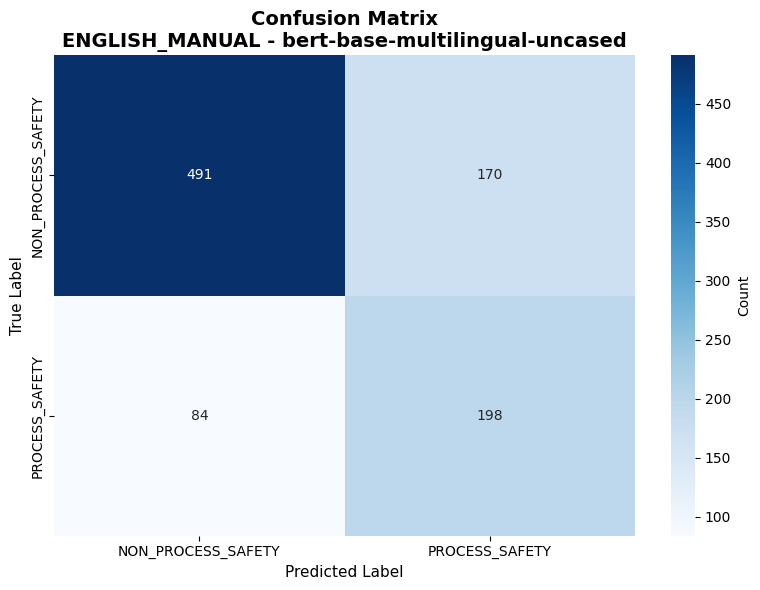


Training SVM: GERMANY_MANUAL | Model: bert-base-multilingual-uncased
Training samples: 6000
Test samples: 2991

Training LinearSVC...
Training completed in 6.78s

Accuracy: 0.7920
F1 Score (weighted): 0.8183
F1 Score (macro): 0.6161

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9321    0.8263    0.8760      2659
    Process Safety     0.2713    0.5181    0.3561       332

          accuracy                         0.7920      2991
         macro avg     0.6017    0.6722    0.6161      2991
      weighted avg     0.8588    0.7920    0.8183      2991


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/iter3_cm_germany_manual_bert-base-multilingual-uncased.png


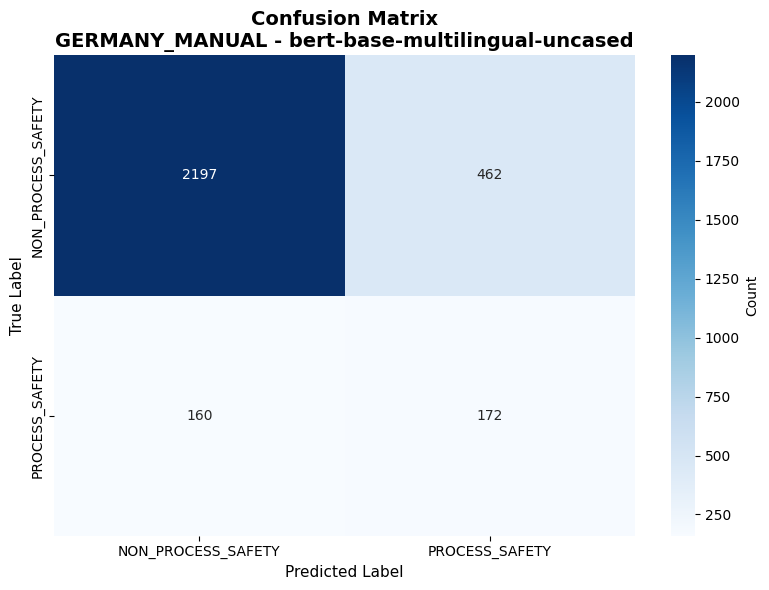


Training SVM: SWEDEN_MANUAL | Model: bert-base-multilingual-uncased
Training samples: 6000
Test samples: 2445

Training LinearSVC...


/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training completed in 21.44s

Accuracy: 0.8613
F1 Score (weighted): 0.8783
F1 Score (macro): 0.5632

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9485    0.9009    0.9241      2290
    Process Safety     0.1593    0.2774    0.2024       155

          accuracy                         0.8613      2445
         macro avg     0.5539    0.5891    0.5632      2445
      weighted avg     0.8985    0.8613    0.8783      2445


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/iter3_cm_sweden_manual_bert-base-multilingual-uncased.png


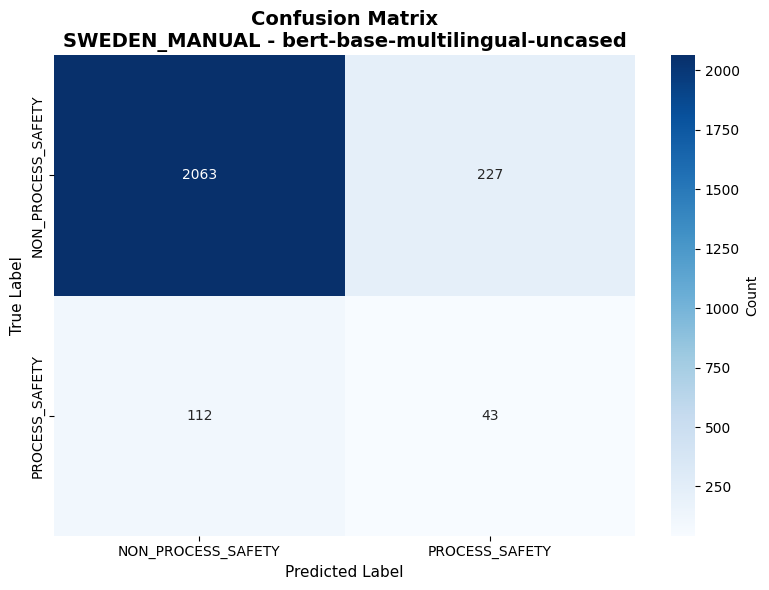


Training SVM: NETHERLANDS_MANUAL | Model: bert-base-multilingual-uncased
Training samples: 1592
Test samples: 398

Training LinearSVC...
Training completed in 5.54s

Accuracy: 0.6281
F1 Score (weighted): 0.6338
F1 Score (macro): 0.5685

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.7481    0.7107    0.7289       280
    Process Safety     0.3864    0.4322    0.4080       118

          accuracy                         0.6281       398
         macro avg     0.5672    0.5715    0.5685       398
      weighted avg     0.6409    0.6281    0.6338       398


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/iter3_cm_netherlands_manual_bert-base-multilingual-uncased.png


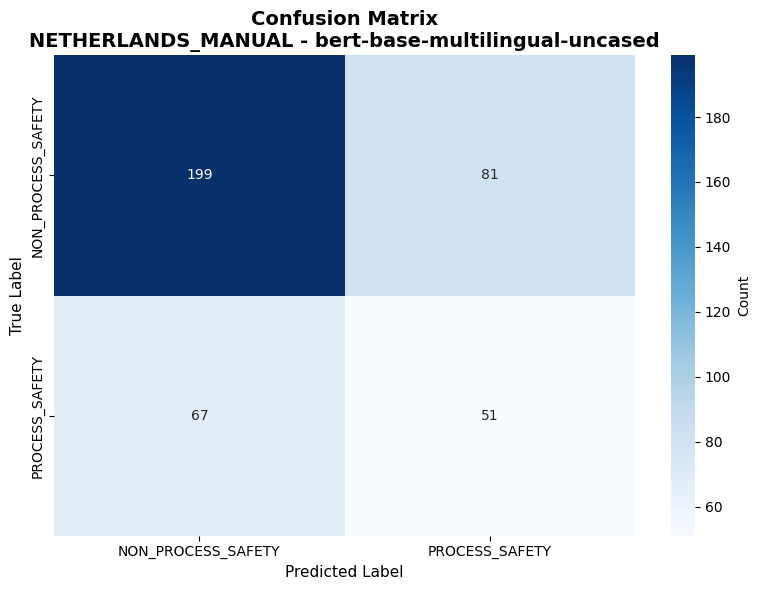


 Completed processing bert-base-multilingual-uncased

################################################################################
MODEL: bert-base-multilingual-cased (google-bert/bert-base-multilingual-cased)
################################################################################

Initializing bert-base-multilingual-cased...
 Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - bert-base-multilingual-cased

Processing: ENGLISH_MANUAL
Model: bert-base-multilingual-cased (google-bert/bert-base-multilingual-cased)
Dataset shape: (4713, 36)

Case type distribution:
CASE_TYPE
Safety                              2553
Process Safety                      1409
Environment                          454
Asset and Reputation damage/loss     145
Operational loss                     123
Physical Security                     14
Information Security                  12
Not classified                         3
Name: count, dtype: int64

Generating google-bert/bert-base-multilingua

Generating embeddings: 100%|██████████| 393/393 [02:56<00:00,  2.22it/s]



Training set: (3770, 768)
Test set: (943, 768)

Class distribution in training set:
binary_label
0    70.11%
1    29.89%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/bert-base-multilingual-cased/english_manual_bert-base-multilingual-cased_embeddings.pkl
Size: 15.36 MB

Checkpoint saved: 5 combinations processed
Progress: 5/20

Processing: GERMANY_MANUAL
Model: bert-base-multilingual-cased (google-bert/bert-base-multilingual-cased)
Dataset shape: (14951, 36)

Case type distribution:
CASE_TYPE
Safety                              11506
Process Safety                       1661
Environment                          1038
Asset and Reputation damage/loss      518
Information Security                  156
Operational loss                       39
Physical Security                      30
Not classified                          3
Name: count, dtype: int64

Generating google-bert/bert-base-multili

Generating embeddings: 100%|██████████| 1246/1246 [07:31<00:00,  2.76it/s]



Training set: (11960, 768)
Test set: (2991, 768)

Subsampling to 6000 samples for SVM efficiency...
Subsampled training set: (6000, 768)

Class distribution in training set:
binary_label
0    88.89%
1    11.11%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/bert-base-multilingual-cased/germany_manual_bert-base-multilingual-cased_embeddings.pkl
Size: 65.05 MB

Checkpoint saved: 6 combinations processed
Progress: 6/20

Processing: SWEDEN_MANUAL
Model: bert-base-multilingual-cased (google-bert/bert-base-multilingual-cased)
Dataset shape: (12224, 36)

Case type distribution:
CASE_TYPE
Safety                              9974
Process Safety                       773
Environment                          681
Asset and Reputation damage/loss     549
Operational loss                     247
Name: count, dtype: int64

Generating google-bert/bert-base-multilingual-cased embeddings...
Using device: mp

Generating embeddings: 100%|██████████| 1019/1019 [04:55<00:00,  3.45it/s]



Training set: (9779, 768)
Test set: (2445, 768)

Subsampling to 6000 samples for SVM efficiency...
Subsampled training set: (6000, 768)

Class distribution in training set:
binary_label
0    93.68%
1     6.32%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/bert-base-multilingual-cased/sweden_manual_bert-base-multilingual-cased_embeddings.pkl
Size: 54.97 MB

Checkpoint saved: 7 combinations processed
Progress: 7/20

Processing: NETHERLANDS_MANUAL
Model: bert-base-multilingual-cased (google-bert/bert-base-multilingual-cased)
Dataset shape: (1990, 36)

Case type distribution:
CASE_TYPE
Safety                              649
Process Safety                      588
Environment                         536
Asset and Reputation damage/loss    110
Operational loss                     45
Physical Security                    45
Information Security                 17
Name: count, dtype: int64

Gener

Generating embeddings: 100%|██████████| 166/166 [03:02<00:00,  1.10s/it]



Training set: (1592, 768)
Test set: (398, 768)

Class distribution in training set:
binary_label
0    70.48%
1    29.52%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/bert-base-multilingual-cased/netherlands_manual_bert-base-multilingual-cased_embeddings.pkl
Size: 6.60 MB

Checkpoint saved: 8 combinations processed
Progress: 8/20

PHASE 2: TRAINING SVM - bert-base-multilingual-cased

Training SVM: ENGLISH_MANUAL | Model: bert-base-multilingual-cased
Training samples: 3770
Test samples: 943

Training LinearSVC...
Training completed in 2.37s

Accuracy: 0.7370
F1 Score (weighted): 0.7440
F1 Score (macro): 0.7049

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8482    0.7610    0.8022       661
    Process Safety     0.5486    0.6809    0.6076       282

          accuracy                         0.7370       943
         macro avg

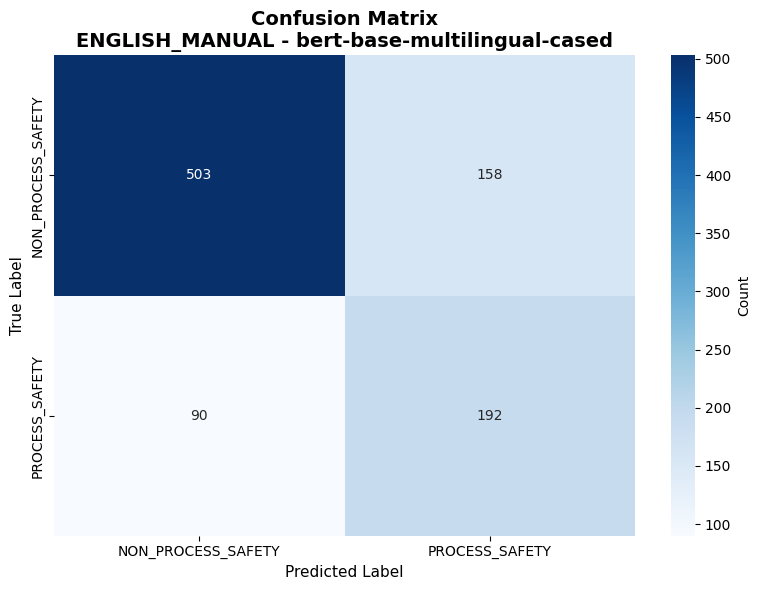


Training SVM: GERMANY_MANUAL | Model: bert-base-multilingual-cased
Training samples: 6000
Test samples: 2991

Training LinearSVC...
Training completed in 5.55s

Accuracy: 0.7971
F1 Score (weighted): 0.8233
F1 Score (macro): 0.6293

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9377    0.8266    0.8787      2659
    Process Safety     0.2875    0.5602    0.3800       332

          accuracy                         0.7971      2991
         macro avg     0.6126    0.6934    0.6293      2991
      weighted avg     0.8655    0.7971    0.8233      2991


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/iter3_cm_germany_manual_bert-base-multilingual-cased.png


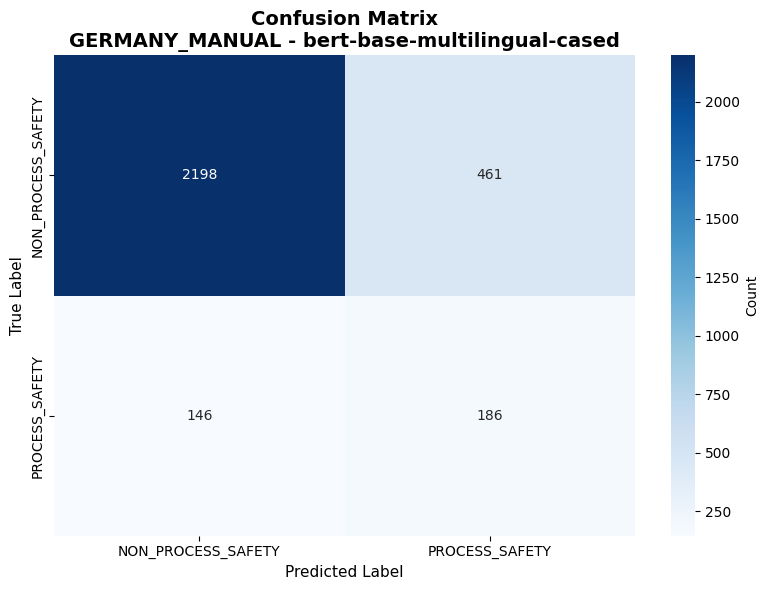


Training SVM: SWEDEN_MANUAL | Model: bert-base-multilingual-cased
Training samples: 6000
Test samples: 2445

Training LinearSVC...


/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training completed in 67.98s

Accuracy: 0.8450
F1 Score (weighted): 0.8674
F1 Score (macro): 0.5426

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9459    0.8852    0.9145      2290
    Process Safety     0.1291    0.2516    0.1707       155

          accuracy                         0.8450      2445
         macro avg     0.5375    0.5684    0.5426      2445
      weighted avg     0.8941    0.8450    0.8674      2445


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/iter3_cm_sweden_manual_bert-base-multilingual-cased.png


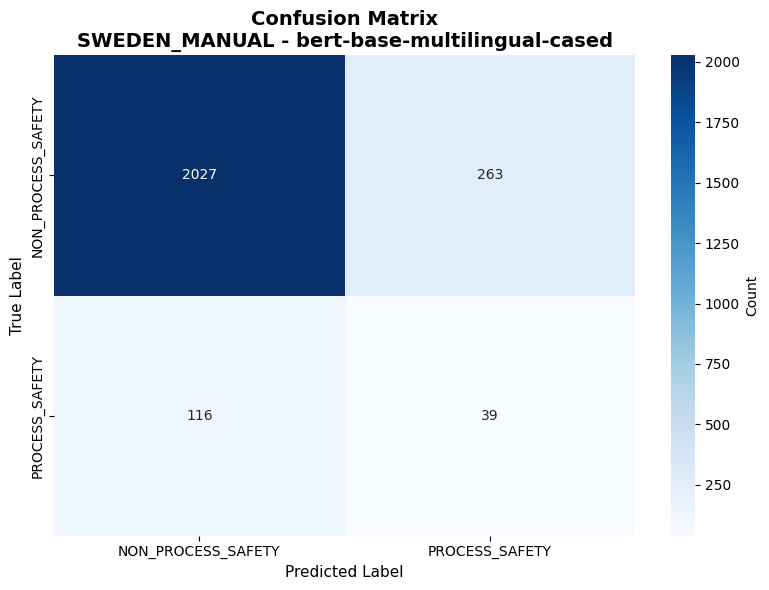


Training SVM: NETHERLANDS_MANUAL | Model: bert-base-multilingual-cased
Training samples: 1592
Test samples: 398

Training LinearSVC...
Training completed in 11.55s

Accuracy: 0.6382
F1 Score (weighted): 0.6462
F1 Score (macro): 0.5871

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.7636    0.7036    0.7323       280
    Process Safety     0.4071    0.4831    0.4419       118

          accuracy                         0.6382       398
         macro avg     0.5854    0.5933    0.5871       398
      weighted avg     0.6579    0.6382    0.6462       398


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/iter3_cm_netherlands_manual_bert-base-multilingual-cased.png


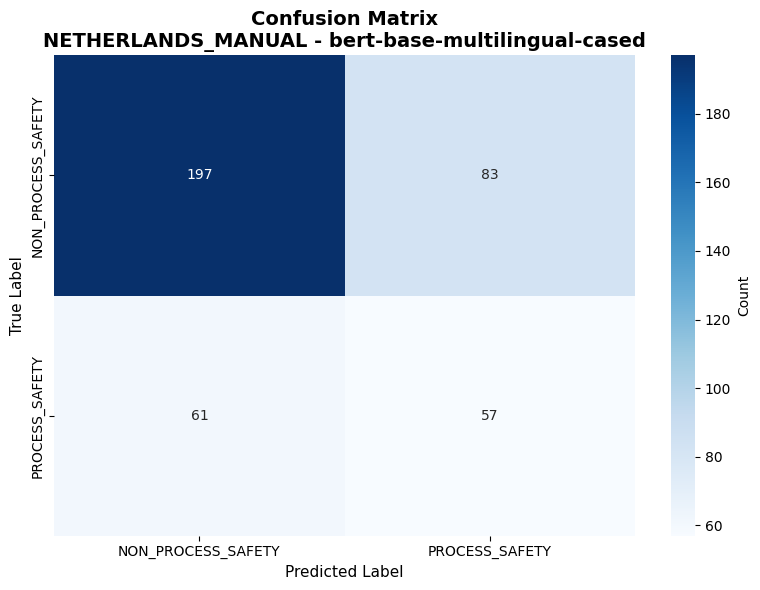


 Completed processing bert-base-multilingual-cased

################################################################################
MODEL: intfloat/multilingual-e5-base (intfloat/multilingual-e5-base)
################################################################################

Initializing intfloat/multilingual-e5-base...
 Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - intfloat/multilingual-e5-base

Processing: ENGLISH_MANUAL
Model: intfloat/multilingual-e5-base (intfloat/multilingual-e5-base)
Dataset shape: (4713, 36)

Case type distribution:
CASE_TYPE
Safety                              2553
Process Safety                      1409
Environment                          454
Asset and Reputation damage/loss     145
Operational loss                     123
Physical Security                     14
Information Security                  12
Not classified                         3
Name: count, dtype: int64

Generating intfloat/multilingual-e5-base embeddings...
Using dev

Generating embeddings: 100%|██████████| 393/393 [02:24<00:00,  2.72it/s]



Training set: (3770, 768)
Test set: (943, 768)

Class distribution in training set:
binary_label
0    70.11%
1    29.89%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/intfloat_multilingual-e5-base/english_manual_intfloat_multilingual-e5-base_embeddings.pkl
Size: 15.36 MB

Checkpoint saved: 9 combinations processed
Progress: 9/20

Processing: GERMANY_MANUAL
Model: intfloat/multilingual-e5-base (intfloat/multilingual-e5-base)
Dataset shape: (14951, 36)

Case type distribution:
CASE_TYPE
Safety                              11506
Process Safety                       1661
Environment                          1038
Asset and Reputation damage/loss      518
Information Security                  156
Operational loss                       39
Physical Security                      30
Not classified                          3
Name: count, dtype: int64

Generating intfloat/multilingual-e5-base embeddi

Generating embeddings: 100%|██████████| 1246/1246 [08:18<00:00,  2.50it/s]



Training set: (11960, 768)
Test set: (2991, 768)

Subsampling to 6000 samples for SVM efficiency...
Subsampled training set: (6000, 768)

Class distribution in training set:
binary_label
0    88.89%
1    11.11%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/intfloat_multilingual-e5-base/germany_manual_intfloat_multilingual-e5-base_embeddings.pkl
Size: 65.05 MB

Checkpoint saved: 10 combinations processed
Progress: 10/20

Processing: SWEDEN_MANUAL
Model: intfloat/multilingual-e5-base (intfloat/multilingual-e5-base)
Dataset shape: (12224, 36)

Case type distribution:
CASE_TYPE
Safety                              9974
Process Safety                       773
Environment                          681
Asset and Reputation damage/loss     549
Operational loss                     247
Name: count, dtype: int64

Generating intfloat/multilingual-e5-base embeddings...
Using device: mps


Generating embeddings: 100%|██████████| 1019/1019 [03:31<00:00,  4.82it/s]



Training set: (9779, 768)
Test set: (2445, 768)

Subsampling to 6000 samples for SVM efficiency...
Subsampled training set: (6000, 768)

Class distribution in training set:
binary_label
0    93.68%
1     6.32%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/intfloat_multilingual-e5-base/sweden_manual_intfloat_multilingual-e5-base_embeddings.pkl
Size: 54.97 MB

Checkpoint saved: 11 combinations processed
Progress: 11/20

Processing: NETHERLANDS_MANUAL
Model: intfloat/multilingual-e5-base (intfloat/multilingual-e5-base)
Dataset shape: (1990, 36)

Case type distribution:
CASE_TYPE
Safety                              649
Process Safety                      588
Environment                         536
Asset and Reputation damage/loss    110
Operational loss                     45
Physical Security                    45
Information Security                 17
Name: count, dtype: int64

Generating 

Generating embeddings: 100%|██████████| 166/166 [01:11<00:00,  2.31it/s]



Training set: (1592, 768)
Test set: (398, 768)

Class distribution in training set:
binary_label
0    70.48%
1    29.52%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/intfloat_multilingual-e5-base/netherlands_manual_intfloat_multilingual-e5-base_embeddings.pkl
Size: 6.60 MB

Checkpoint saved: 12 combinations processed
Progress: 12/20

PHASE 2: TRAINING SVM - intfloat/multilingual-e5-base

Training SVM: ENGLISH_MANUAL | Model: intfloat/multilingual-e5-base
Training samples: 3770
Test samples: 943

Training LinearSVC...
Training completed in 2.30s

Accuracy: 0.7614
F1 Score (weighted): 0.7680
F1 Score (macro): 0.7329

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8695    0.7761    0.8201       661
    Process Safety     0.5807    0.7270    0.6457       282

          accuracy                         0.7614       943
         mac

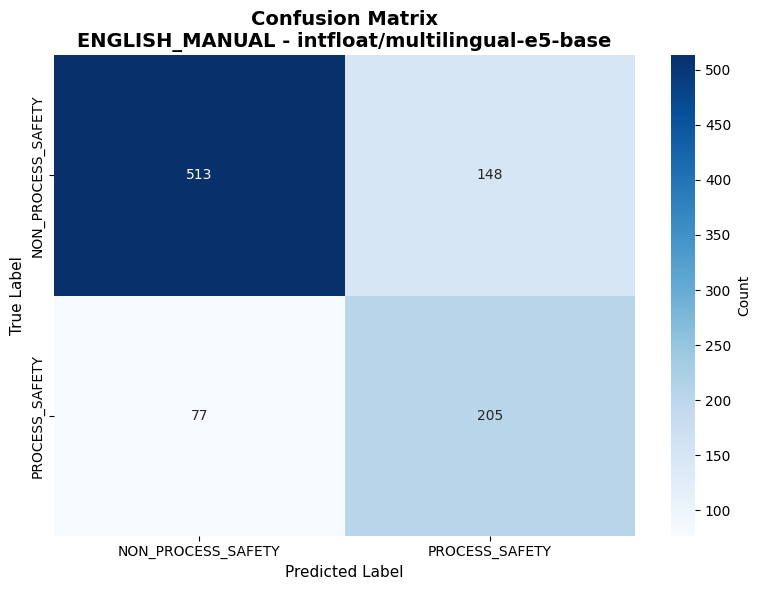


Training SVM: GERMANY_MANUAL | Model: intfloat/multilingual-e5-base
Training samples: 6000
Test samples: 2991

Training LinearSVC...
Training completed in 6.00s

Accuracy: 0.8131
F1 Score (weighted): 0.8353
F1 Score (macro): 0.6463

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9401    0.8436    0.8892      2659
    Process Safety     0.3124    0.5693    0.4034       332

          accuracy                         0.8131      2991
         macro avg     0.6262    0.7064    0.6463      2991
      weighted avg     0.8704    0.8131    0.8353      2991


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/iter3_cm_germany_manual_intfloat_multilingual-e5-base.png


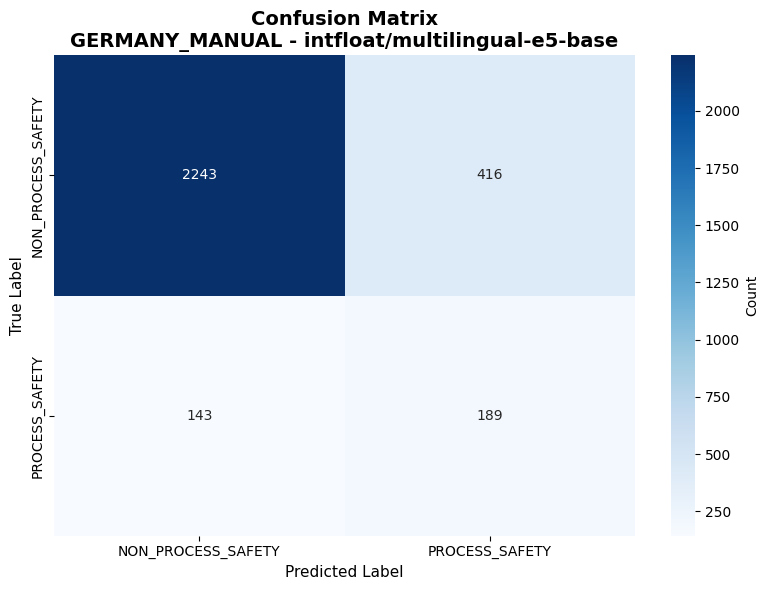


Training SVM: SWEDEN_MANUAL | Model: intfloat/multilingual-e5-base
Training samples: 6000
Test samples: 2445

Training LinearSVC...


/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training completed in 32.50s

Accuracy: 0.8564
F1 Score (weighted): 0.8753
F1 Score (macro): 0.5590

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9482    0.8956    0.9212      2290
    Process Safety     0.1525    0.2774    0.1968       155

          accuracy                         0.8564      2445
         macro avg     0.5504    0.5865    0.5590      2445
      weighted avg     0.8978    0.8564    0.8753      2445


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/iter3_cm_sweden_manual_intfloat_multilingual-e5-base.png


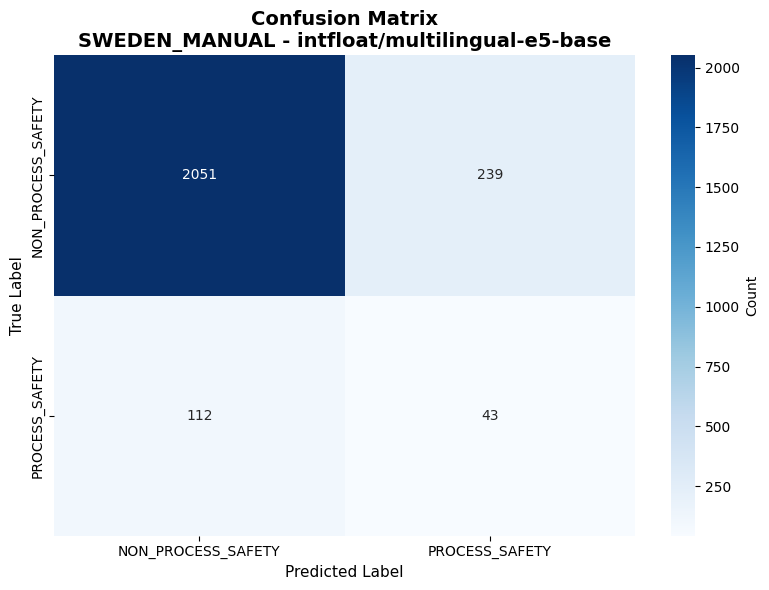


Training SVM: NETHERLANDS_MANUAL | Model: intfloat/multilingual-e5-base
Training samples: 1592
Test samples: 398

Training LinearSVC...
Training completed in 6.04s

Accuracy: 0.7136
F1 Score (weighted): 0.7179
F1 Score (macro): 0.6676

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8120    0.7714    0.7912       280
    Process Safety     0.5152    0.5763    0.5440       118

          accuracy                         0.7136       398
         macro avg     0.6636    0.6738    0.6676       398
      weighted avg     0.7240    0.7136    0.7179       398


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/iter3_cm_netherlands_manual_intfloat_multilingual-e5-base.png


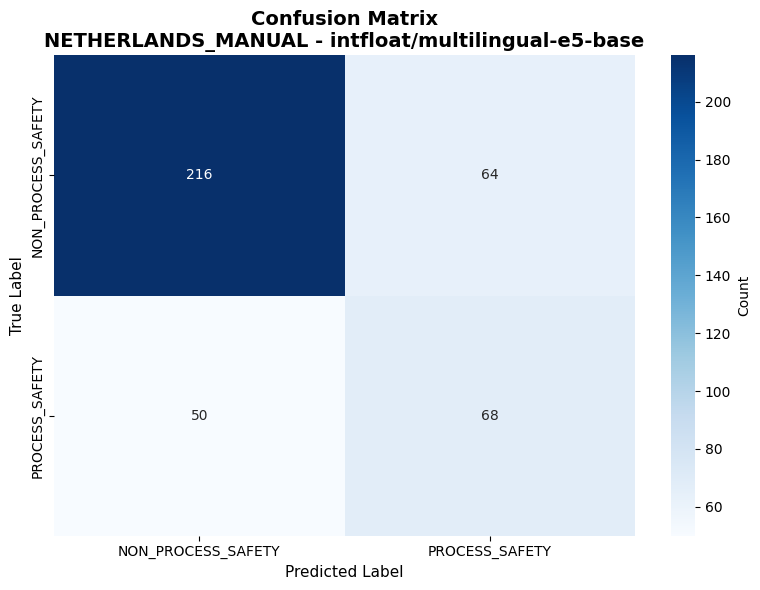


 Completed processing intfloat/multilingual-e5-base

################################################################################
MODEL: intfloat/multilingual-e5-large (intfloat/multilingual-e5-large)
################################################################################

Initializing intfloat/multilingual-e5-large...
 Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - intfloat/multilingual-e5-large

Processing: ENGLISH_MANUAL
Model: intfloat/multilingual-e5-large (intfloat/multilingual-e5-large)
Dataset shape: (4713, 36)

Case type distribution:
CASE_TYPE
Safety                              2553
Process Safety                      1409
Environment                          454
Asset and Reputation damage/loss     145
Operational loss                     123
Physical Security                     14
Information Security                  12
Not classified                         3
Name: count, dtype: int64

Generating intfloat/multilingual-e5-large embeddings...
U

Generating embeddings: 100%|██████████| 393/393 [10:43<00:00,  1.64s/it]



Training set: (3770, 1024)
Test set: (943, 1024)

Class distribution in training set:
binary_label
0    70.11%
1    29.89%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/intfloat_multilingual-e5-large/english_manual_intfloat_multilingual-e5-large_embeddings.pkl
Size: 19.96 MB

Checkpoint saved: 13 combinations processed
Progress: 13/20

Processing: GERMANY_MANUAL
Model: intfloat/multilingual-e5-large (intfloat/multilingual-e5-large)
Dataset shape: (14951, 36)

Case type distribution:
CASE_TYPE
Safety                              11506
Process Safety                       1661
Environment                          1038
Asset and Reputation damage/loss      518
Information Security                  156
Operational loss                       39
Physical Security                      30
Not classified                          3
Name: count, dtype: int64

Generating intfloat/multilingual-e5-larg

Generating embeddings: 100%|██████████| 1246/1246 [21:15<00:00,  1.02s/it]



Training set: (11960, 1024)
Test set: (2991, 1024)

Subsampling to 6000 samples for SVM efficiency...
Subsampled training set: (6000, 1024)

Class distribution in training set:
binary_label
0    88.89%
1    11.11%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/intfloat_multilingual-e5-large/germany_manual_intfloat_multilingual-e5-large_embeddings.pkl
Size: 85.51 MB

Checkpoint saved: 14 combinations processed
Progress: 14/20

Processing: SWEDEN_MANUAL
Model: intfloat/multilingual-e5-large (intfloat/multilingual-e5-large)
Dataset shape: (12224, 36)

Case type distribution:
CASE_TYPE
Safety                              9974
Process Safety                       773
Environment                          681
Asset and Reputation damage/loss     549
Operational loss                     247
Name: count, dtype: int64

Generating intfloat/multilingual-e5-large embeddings...
Using device: mps


Generating embeddings: 100%|██████████| 1019/1019 [07:11<00:00,  2.36it/s]



Training set: (9779, 1024)
Test set: (2445, 1024)

Subsampling to 6000 samples for SVM efficiency...
Subsampled training set: (6000, 1024)

Class distribution in training set:
binary_label
0    93.68%
1     6.32%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/intfloat_multilingual-e5-large/sweden_manual_intfloat_multilingual-e5-large_embeddings.pkl
Size: 72.77 MB

Checkpoint saved: 15 combinations processed
Progress: 15/20

Processing: NETHERLANDS_MANUAL
Model: intfloat/multilingual-e5-large (intfloat/multilingual-e5-large)
Dataset shape: (1990, 36)

Case type distribution:
CASE_TYPE
Safety                              649
Process Safety                      588
Environment                         536
Asset and Reputation damage/loss    110
Operational loss                     45
Physical Security                    45
Information Security                 17
Name: count, dtype: int64

Gene

Generating embeddings: 100%|██████████| 166/166 [04:30<00:00,  1.63s/it]



Training set: (1592, 1024)
Test set: (398, 1024)

Class distribution in training set:
binary_label
0    70.48%
1    29.52%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/intfloat_multilingual-e5-large/netherlands_manual_intfloat_multilingual-e5-large_embeddings.pkl
Size: 8.54 MB

Checkpoint saved: 16 combinations processed
Progress: 16/20

PHASE 2: TRAINING SVM - intfloat/multilingual-e5-large

Training SVM: ENGLISH_MANUAL | Model: intfloat/multilingual-e5-large
Training samples: 3770
Test samples: 943

Training LinearSVC...
Training completed in 2.49s

Accuracy: 0.7625
F1 Score (weighted): 0.7681
F1 Score (macro): 0.7313

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8624    0.7867    0.8228       661
    Process Safety     0.5853    0.7057    0.6399       282

          accuracy                         0.7625       943
      

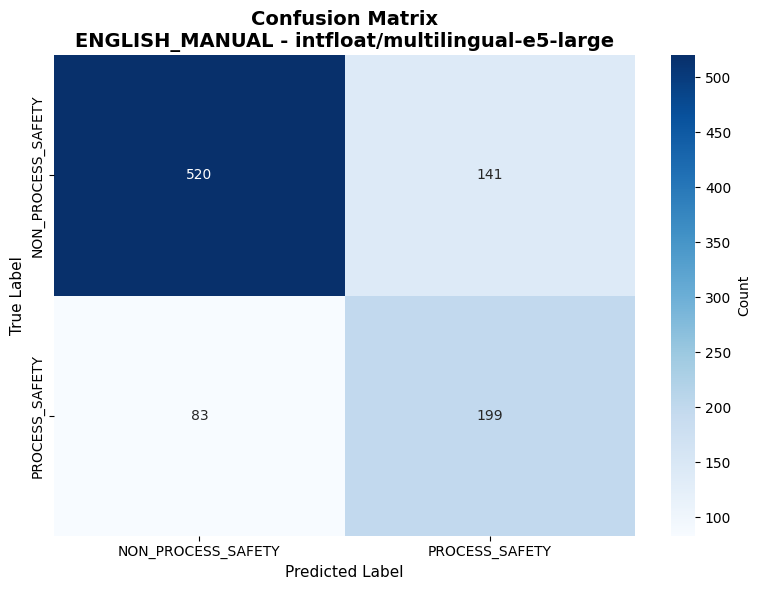


Training SVM: GERMANY_MANUAL | Model: intfloat/multilingual-e5-large
Training samples: 6000
Test samples: 2991

Training LinearSVC...


/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training completed in 34.95s

Accuracy: 0.8382
F1 Score (weighted): 0.8502
F1 Score (macro): 0.6530

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9321    0.8823    0.9065      2659
    Process Safety     0.3397    0.4849    0.3995       332

          accuracy                         0.8382      2991
         macro avg     0.6359    0.6836    0.6530      2991
      weighted avg     0.8663    0.8382    0.8502      2991


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/iter3_cm_germany_manual_intfloat_multilingual-e5-large.png


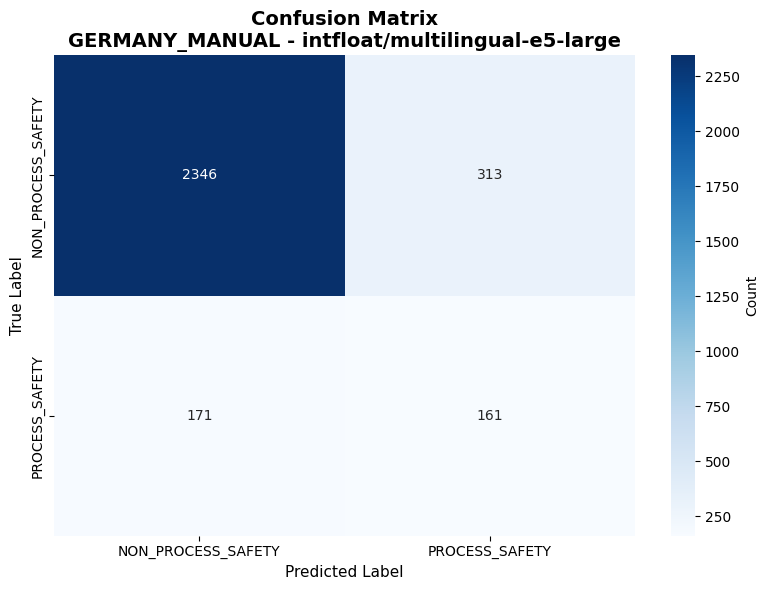


Training SVM: SWEDEN_MANUAL | Model: intfloat/multilingual-e5-large
Training samples: 6000
Test samples: 2445

Training LinearSVC...


/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training completed in 27.19s

Accuracy: 0.8773
F1 Score (weighted): 0.8859
F1 Score (macro): 0.5570

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9454    0.9223    0.9337      2290
    Process Safety     0.1564    0.2129    0.1803       155

          accuracy                         0.8773      2445
         macro avg     0.5509    0.5676    0.5570      2445
      weighted avg     0.8954    0.8773    0.8859      2445


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/iter3_cm_sweden_manual_intfloat_multilingual-e5-large.png


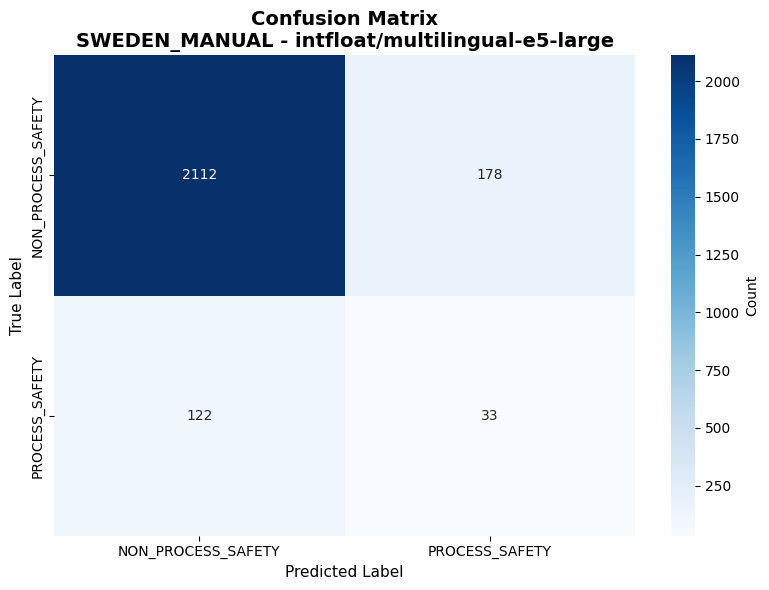


Training SVM: NETHERLANDS_MANUAL | Model: intfloat/multilingual-e5-large
Training samples: 1592
Test samples: 398

Training LinearSVC...
Training completed in 11.70s

Accuracy: 0.6734
F1 Score (weighted): 0.6708
F1 Score (macro): 0.6026

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.7622    0.7786    0.7703       280
    Process Safety     0.4464    0.4237    0.4348       118

          accuracy                         0.6734       398
         macro avg     0.6043    0.6012    0.6026       398
      weighted avg     0.6686    0.6734    0.6708       398


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/iter3_cm_netherlands_manual_intfloat_multilingual-e5-large.png


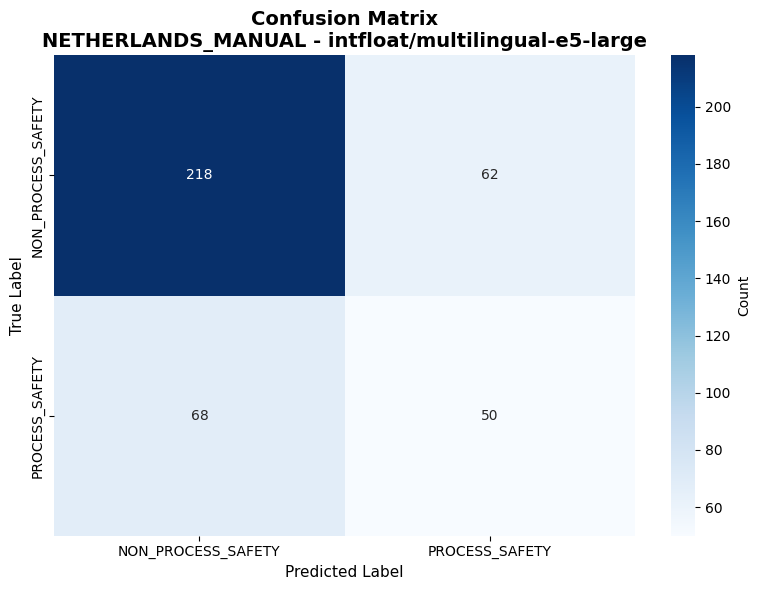


 Completed processing intfloat/multilingual-e5-large

################################################################################
MODEL: intfloat/multilingual-e5-large-instruct (intfloat/multilingual-e5-large-instruct)
################################################################################

Initializing intfloat/multilingual-e5-large-instruct...
 Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - intfloat/multilingual-e5-large-instruct

Processing: ENGLISH_MANUAL
Model: intfloat/multilingual-e5-large-instruct (intfloat/multilingual-e5-large-instruct)
Dataset shape: (4713, 36)

Case type distribution:
CASE_TYPE
Safety                              2553
Process Safety                      1409
Environment                          454
Asset and Reputation damage/loss     145
Operational loss                     123
Physical Security                     14
Information Security                  12
Not classified                         3
Name: count, dtype: int64

Ge

Generating embeddings: 100%|██████████| 393/393 [10:28<00:00,  1.60s/it]



Training set: (3770, 1024)
Test set: (943, 1024)

Class distribution in training set:
binary_label
0    70.11%
1    29.89%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/intfloat_multilingual-e5-large-instruct/english_manual_intfloat_multilingual-e5-large-instruct_embeddings.pkl
Size: 19.96 MB

Checkpoint saved: 17 combinations processed
Progress: 17/20

Processing: GERMANY_MANUAL
Model: intfloat/multilingual-e5-large-instruct (intfloat/multilingual-e5-large-instruct)
Dataset shape: (14951, 36)

Case type distribution:
CASE_TYPE
Safety                              11506
Process Safety                       1661
Environment                          1038
Asset and Reputation damage/loss      518
Information Security                  156
Operational loss                       39
Physical Security                      30
Not classified                          3
Name: count, dtype: int64

Gene

Generating embeddings: 100%|██████████| 1246/1246 [12:21<00:00,  1.68it/s]



Training set: (11960, 1024)
Test set: (2991, 1024)

Subsampling to 6000 samples for SVM efficiency...
Subsampled training set: (6000, 1024)

Class distribution in training set:
binary_label
0    88.89%
1    11.11%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/intfloat_multilingual-e5-large-instruct/germany_manual_intfloat_multilingual-e5-large-instruct_embeddings.pkl
Size: 85.51 MB

Checkpoint saved: 18 combinations processed
Progress: 18/20

Processing: SWEDEN_MANUAL
Model: intfloat/multilingual-e5-large-instruct (intfloat/multilingual-e5-large-instruct)
Dataset shape: (12224, 36)

Case type distribution:
CASE_TYPE
Safety                              9974
Process Safety                       773
Environment                          681
Asset and Reputation damage/loss     549
Operational loss                     247
Name: count, dtype: int64

Generating intfloat/multilingual-e5-large-ins

Generating embeddings: 100%|██████████| 1019/1019 [04:25<00:00,  3.85it/s]



Training set: (9779, 1024)
Test set: (2445, 1024)

Subsampling to 6000 samples for SVM efficiency...
Subsampled training set: (6000, 1024)

Class distribution in training set:
binary_label
0    93.68%
1     6.32%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/intfloat_multilingual-e5-large-instruct/sweden_manual_intfloat_multilingual-e5-large-instruct_embeddings.pkl
Size: 72.77 MB

Checkpoint saved: 19 combinations processed
Progress: 19/20

Processing: NETHERLANDS_MANUAL
Model: intfloat/multilingual-e5-large-instruct (intfloat/multilingual-e5-large-instruct)
Dataset shape: (1990, 36)

Case type distribution:
CASE_TYPE
Safety                              649
Process Safety                      588
Environment                         536
Asset and Reputation damage/loss    110
Operational loss                     45
Physical Security                    45
Information Security               

Generating embeddings: 100%|██████████| 166/166 [03:06<00:00,  1.12s/it]



Training set: (1592, 1024)
Test set: (398, 1024)

Class distribution in training set:
binary_label
0    70.48%
1    29.52%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/intfloat_multilingual-e5-large-instruct/netherlands_manual_intfloat_multilingual-e5-large-instruct_embeddings.pkl
Size: 8.54 MB

Checkpoint saved: 20 combinations processed
Progress: 20/20

PHASE 2: TRAINING SVM - intfloat/multilingual-e5-large-instruct

Training SVM: ENGLISH_MANUAL | Model: intfloat/multilingual-e5-large-instruct
Training samples: 3770
Test samples: 943

Training LinearSVC...
Training completed in 1.91s

Accuracy: 0.7646
F1 Score (weighted): 0.7689
F1 Score (macro): 0.7301

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8546    0.8003    0.8266       661
    Process Safety     0.5926    0.6809    0.6337       282

          accuracy            

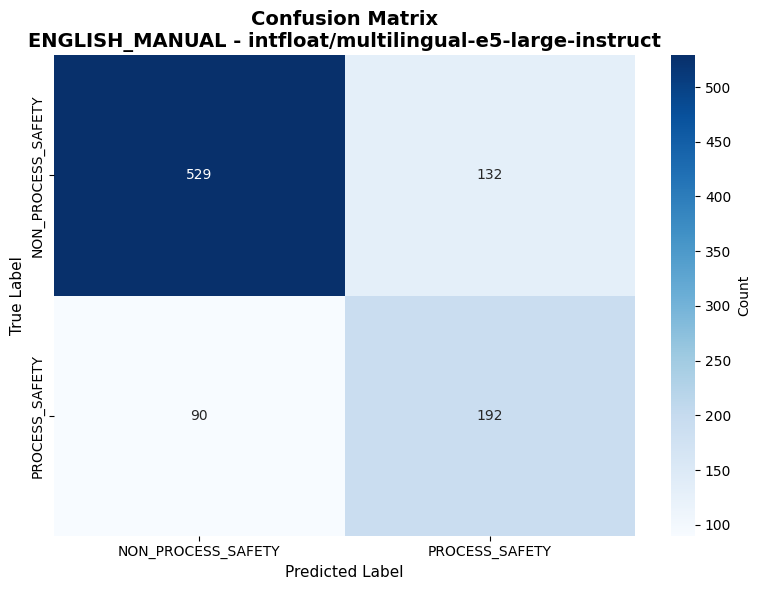


Training SVM: GERMANY_MANUAL | Model: intfloat/multilingual-e5-large-instruct
Training samples: 6000
Test samples: 2991

Training LinearSVC...


/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training completed in 14.44s

Accuracy: 0.8308
F1 Score (weighted): 0.8474
F1 Score (macro): 0.6597

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9389    0.8661    0.9010      2659
    Process Safety     0.3383    0.5482    0.4184       332

          accuracy                         0.8308      2991
         macro avg     0.6386    0.7072    0.6597      2991
      weighted avg     0.8722    0.8308    0.8474      2991


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/iter3_cm_germany_manual_intfloat_multilingual-e5-large-instruct.png


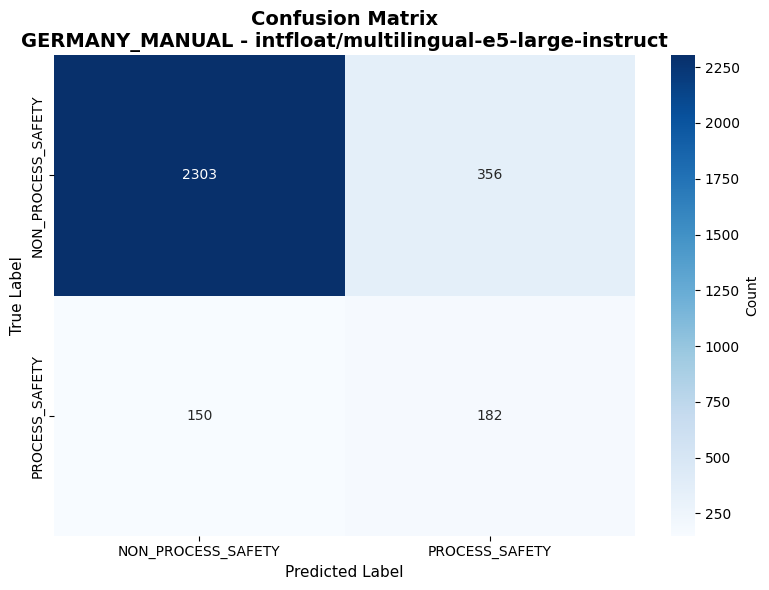


Training SVM: SWEDEN_MANUAL | Model: intfloat/multilingual-e5-large-instruct
Training samples: 6000
Test samples: 2445

Training LinearSVC...


/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training completed in 10.87s

Accuracy: 0.8765
F1 Score (weighted): 0.8874
F1 Score (macro): 0.5733

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9486    0.9179    0.9330      2290
    Process Safety     0.1790    0.2645    0.2135       155

          accuracy                         0.8765      2445
         macro avg     0.5638    0.5912    0.5733      2445
      weighted avg     0.8998    0.8765    0.8874      2445


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/iter3_cm_sweden_manual_intfloat_multilingual-e5-large-instruct.png


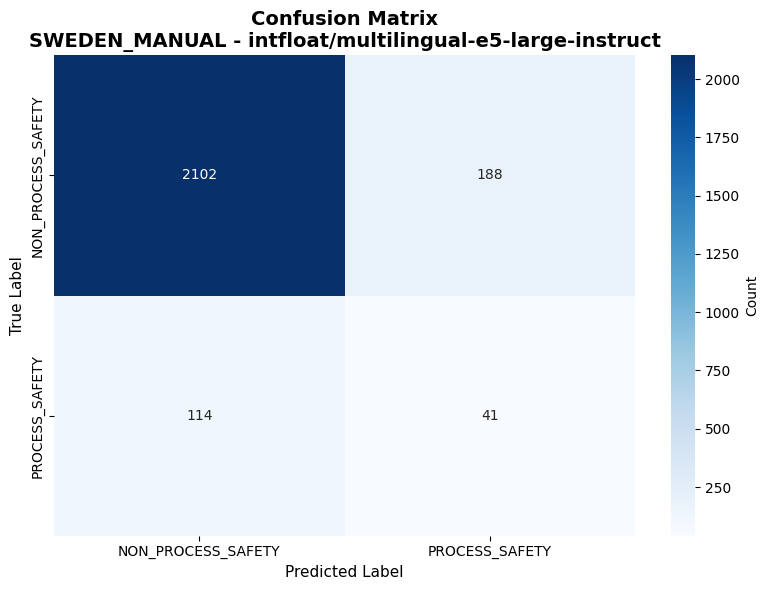


Training SVM: NETHERLANDS_MANUAL | Model: intfloat/multilingual-e5-large-instruct
Training samples: 1592
Test samples: 398

Training LinearSVC...
Training completed in 5.04s

Accuracy: 0.7312
F1 Score (weighted): 0.7321
F1 Score (macro): 0.6801

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8123    0.8036    0.8079       280
    Process Safety     0.5455    0.5593    0.5523       118

          accuracy                         0.7312       398
         macro avg     0.6789    0.6814    0.6801       398
      weighted avg     0.7332    0.7312    0.7321       398


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/iter3_cm_netherlands_manual_intfloat_multilingual-e5-large-instruct.png


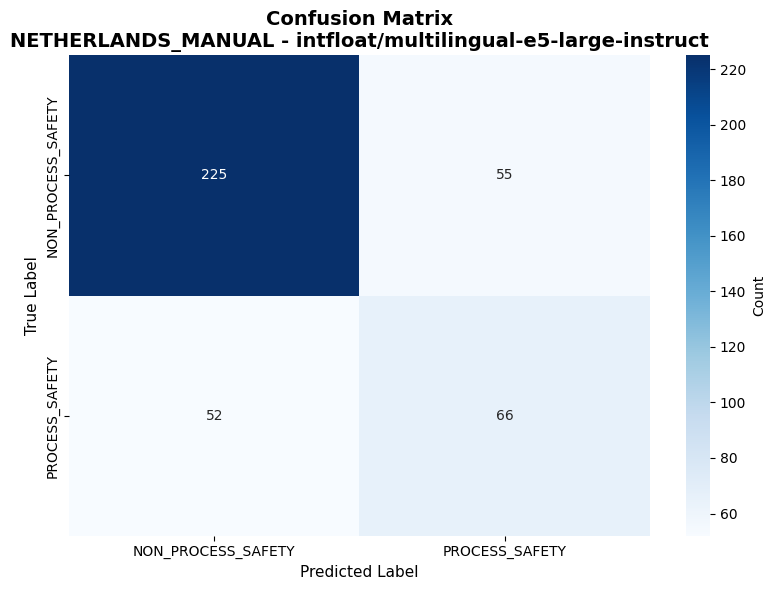


 Completed processing intfloat/multilingual-e5-large-instruct

################################################################################
FINAL COMPREHENSIVE SUMMARY
################################################################################

DETAILED RESULTS TABLE
           dataset                                   model  accuracy  f1_weighted  f1_macro  precision_non_ps  recall_non_ps  f1_non_ps  support_non_ps  precision_ps  recall_ps  f1_ps  support_ps  training_time  subsampled
    english_manual          bert-base-multilingual-uncased    0.7306       0.7391    0.7019            0.8539         0.7428     0.7945             661        0.5380     0.7021 0.6092         282           1.21       False
    germany_manual          bert-base-multilingual-uncased    0.7920       0.8183    0.6161            0.9321         0.8263     0.8760            2659        0.2713     0.5181 0.3561         332           6.78        True
     sweden_manual          bert-base-multilingual-un

In [3]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm
import pickle
import glob
import gc
import json
import time

# ============================================================
# Configuration
# ============================================================

# Use PATHS defined in the setup cell
DATA_DIR = str(PATHS['master_dataset'])
EMBEDDINGS_BASE_DIR = str(PATHS['embeddings'])
RESULTS_DIR = str(PATHS['results'])
CHECKPOINT_FILE = str(PATHS['results'] / "checkpoint_iteration_3.json")

# Create directories
os.makedirs(EMBEDDINGS_BASE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(os.path.dirname(CHECKPOINT_FILE), exist_ok=True)

# Model configurations
MODELS = {
    'bert-base-multilingual-uncased': 'google-bert/bert-base-multilingual-uncased',
    'bert-base-multilingual-cased': 'google-bert/bert-base-multilingual-cased',
    'intfloat/multilingual-e5-base': 'intfloat/multilingual-e5-base',
    'intfloat/multilingual-e5-large': 'intfloat/multilingual-e5-large',
    'intfloat/multilingual-e5-large-instruct': 'intfloat/multilingual-e5-large-instruct'
}

# Datasets to skip
SKIP_DATASETS = [
    'master_df_Hungary_manual.json',
    'master_df_International_manual.json',
    'master_df_Russia_manual.json',
    'master_df_UAE_manual.json',
    'master_df_Poland_manual.json',
    'master_df_Unknown_manual.json',
]

# Processing settings
BATCH_SIZE = 12
MAX_SAMPLES_SVM = 6000

print("\n" + "#"*80)
print("MULTI-MODEL EMBEDDING AND SVM TRAINING PIPELINE")
print("#"*80)
print(f"\nModels: {list(MODELS.keys())}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Max SVM Training Samples: {MAX_SAMPLES_SVM}")

# ============================================================
# Checkpoint Functions
# ============================================================

def save_checkpoint(processed_items):
    """Save checkpoint with processed model-dataset combinations"""
    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump({'processed': list(processed_items)}, f)
    print(f"Checkpoint saved: {len(processed_items)} combinations processed")

def load_checkpoint():
    """Load checkpoint"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            return set(tuple(item) for item in json.load(f)['processed'])
    return set()

def view_progress():
    """View current progress"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            processed = json.load(f)['processed']
            print(f"\n{'='*60}")
            print(f"Progress: {len(processed)} combinations processed")
            print(f"{'='*60}")
            for item in sorted(processed):
                model_key, dataset = item
                print(f"{model_key:30s} → {dataset}")
    else:
        print("\nNo checkpoint found - no progress yet")

def reset_checkpoint():
    """Delete checkpoint to restart"""
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        print("Checkpoint cleared")
    else:
        print("No checkpoint found")

# ============================================================
# Embedding Generation Function
# ============================================================

def get_bert_embeddings(texts, tokenizer, model, max_length=512, batch_size=12):
    """Generate embeddings for a list of texts"""
    embeddings = []
    device = 'mps' if torch.backends.mps.is_available() else 'cpu'
    model = model.to(device)
    
    print(f"Using device: {device}")
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
        batch_texts = texts[i:i + batch_size]
        
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            # Use last hidden state for embeddings
            if hasattr(outputs, 'last_hidden_state'):
                batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            else:
                # Fallback for models with different output structure
                batch_embeddings = outputs[0][:, 0, :].cpu().numpy()
            embeddings.extend(batch_embeddings)
        
        if device == 'mps':
            torch.mps.empty_cache()
        
        # Clear CPU memory periodically
        if i % 50 == 0 and i > 0:
            gc.collect()
    
    return np.array(embeddings)

# ============================================================
# Dataset Processing Function
# ============================================================

def process_dataset(json_file, model_key, model_name, tokenizer, model, dataset_name=None):
    """Process a single JSON dataset and save embeddings"""
    # Always set dataset_name from the key if not provided
    if dataset_name is None:
        dataset_name = os.path.basename(json_file).replace('master_df_', '').replace('.json', '').lower()
    
    print(f"\n{'='*80}")
    print(f"Processing: {dataset_name.upper()}")
    print(f"Model: {model_key} ({model_name})")
    print(f"{'='*80}")
    
    # Load dataset
    df = pd.read_json(json_file)
    if 'LANGUAGE' in df.columns:
        df['LANGUAGE_CODE'] = df['LANGUAGE'].map(LANGUAGE_CODE_MAP).fillna('UN')
    print(f"Dataset shape: {df.shape}")
    print(f"\nCase type distribution:")
    print(df['CASE_TYPE'].value_counts())
    
    # Create binary labels
    df['binary_label'] = df['CASE_TYPE'].apply(lambda x: 1 if x == 'Process Safety' else 0)
    
    # Combine title and description
    df['text_features'] = df['TITLE'] + '. ' + df['CASE_DESCRIPTION']
    
    # Generate embeddings
    print(f"\nGenerating {model_name} embeddings...")
    X = get_bert_embeddings(
        df['text_features'].tolist(), 
        tokenizer, 
        model, 
        batch_size=BATCH_SIZE
    )
    y = df['binary_label']
    
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\nTraining set: {X_train.shape}")
    print(f"Test set: {X_test.shape}")
    
    # Subsample if training set is too large
    if X_train.shape[0] > MAX_SAMPLES_SVM:
        print(f"\n WARNING: Training set too large ({X_train.shape[0]} samples)")
        print(f"Subsampling to {MAX_SAMPLES_SVM} samples for SVM efficiency...")
        from sklearn.utils import resample
        X_train_subset, y_train_subset = resample(
            X_train, y_train, 
            n_samples=MAX_SAMPLES_SVM, 
            stratify=y_train, 
            random_state=42
        )
        print(f"Subsampled training set: {X_train_subset.shape}")
    else:
        X_train_subset = X_train
        y_train_subset = y_train
    
    print(f"\nClass distribution in training set:")
    print(pd.Series(y_train).value_counts(normalize=True).map(lambda x: f"{x:.2%}"))
    
    # Create model-specific directory
    model_dir = os.path.join(EMBEDDINGS_BASE_DIR, model_key.replace('/', '_'))
    os.makedirs(model_dir, exist_ok=True)
    
    # Save embeddings
    embeddings_data = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'X_train_subset': X_train_subset,
        'y_train_subset': y_train_subset,
        'feature_names': df['text_features'].tolist(),
        'metadata': {
            'model': model_name,
            'model_key': model_key,
            'dataset': dataset_name,
            'embedding_dim': X_train.shape[1],
            'train_size': X_train.shape[0],
            'train_subset_size': X_train_subset.shape[0],
            'test_size': X_test.shape[0],
            'random_state': 42,
            'subsampled': X_train.shape[0] > MAX_SAMPLES_SVM
        }
    }
    
    pkl_file = os.path.join(model_dir, f'{dataset_name}_{model_key.replace("/", "_")}_embeddings.pkl')
    
    with open(pkl_file, 'wb') as f:
        pickle.dump(embeddings_data, f)
    
    print(f"\n{'='*60}")
    print(f"Embeddings saved!")
    print(f"Location: {pkl_file}")
    print(f"Size: {os.path.getsize(pkl_file) / 1024**2:.2f} MB")
    print(f"{'='*60}\n")
    
    # Clear memory
    del df, X, y, X_train, X_test, y_train, y_test, X_train_subset, y_train_subset, embeddings_data
    gc.collect()
    
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    
    return pkl_file

# ============================================================
# SVM Training Function
# ============================================================

def train_svm_and_evaluate(embeddings_file):
    """Load embeddings, train SVM, and generate confusion matrix"""
    
    # Load embeddings
    with open(embeddings_file, 'rb') as f:
        embeddings_data = pickle.load(f)
    
    # Use subset for training if available
    X_train = embeddings_data.get('X_train_subset', embeddings_data['X_train'])
    y_train = embeddings_data.get('y_train_subset', embeddings_data['y_train'])
    X_test = embeddings_data['X_test']
    y_test = embeddings_data['y_test']
    metadata = embeddings_data['metadata']
    
    dataset_name = metadata['dataset']
    model_key = metadata['model_key']
    
    print(f"\n{'='*80}")
    print(f"Training SVM: {dataset_name.upper()} | Model: {model_key}")
    print(f"{'='*80}")
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Test samples: {X_test.shape[0]}")
    
    try:
        # Scale features for LinearSVC convergence
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        
        print(f"\nTraining LinearSVC...")
        start_time = time.time()
        
        svm_model = LinearSVC(class_weight='balanced', max_iter=1000, dual=False, random_state=42)
        svm_model.fit(X_train, y_train)
        
        training_time = time.time() - start_time
        print(f"Training completed in {training_time:.2f}s")
        
        # Make predictions
        y_pred = svm_model.predict(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        f1_weighted = f1_score(y_test, y_pred, average='weighted')
        f1_macro = f1_score(y_test, y_pred, average='macro')
        
        # Get per-class metrics
        precision, recall, f1, support = precision_recall_fscore_support(
            y_test, y_pred, average=None, labels=[0, 1]
        )
        
        print(f"\nAccuracy: {accuracy:.4f}")
        print(f"F1 Score (weighted): {f1_weighted:.4f}")
        print(f"F1 Score (macro): {f1_macro:.4f}")
        
        # Print classification report
        print("\nClassification Report:")
        print(classification_report(
            y_test, y_pred,
            target_names=['Non-Process Safety', 'Process Safety'],
            digits=4
        ))
        
        # Create confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        
        # Create visualization
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NON_PROCESS_SAFETY', 'PROCESS_SAFETY'],
            yticklabels=['NON_PROCESS_SAFETY', 'PROCESS_SAFETY'],
            cbar_kws={'label': 'Count'}
        )
        
        plt.title(f'Confusion Matrix\n{dataset_name.upper()} - {model_key}', 
                  fontsize=14, fontweight='bold')
        plt.ylabel('True Label', fontsize=11)
        plt.xlabel('Predicted Label', fontsize=11)
        plt.tight_layout()
        
        # Save plot
        plot_filename = f'iter3_cm_{dataset_name}_{model_key.replace("/", "_")}.png'
        plot_path = os.path.join(RESULTS_DIR, plot_filename)
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f"\n Confusion matrix saved to: {plot_path}")
        plt.show()
        
        # Clear memory
        plt.close()
        del embeddings_data, X_train, X_test, y_train, y_test
        gc.collect()
        
        return {
            'dataset': dataset_name,
            'model': model_key,
            'model_full': metadata['model'],
            'accuracy': accuracy,
            'f1_weighted': f1_weighted,
            'f1_macro': f1_macro,
            'precision_non_ps': precision[0],
            'recall_non_ps': recall[0],
            'f1_non_ps': f1[0],
            'support_non_ps': support[0],
            'precision_ps': precision[1],
            'recall_ps': recall[1],
            'f1_ps': f1[1],
            'support_ps': support[1],
            'training_time': training_time,
            'confusion_matrix': cm.tolist(),
            'pkl_file': os.path.basename(embeddings_file),
            'subsampled': metadata.get('subsampled', False)
        }
        
    except Exception as e:
        print(f"\n ERROR training SVM: {str(e)}")
        del embeddings_data, X_train, X_test, y_train, y_test
        gc.collect()
        raise

# ============================================================
# Main Execution
# ============================================================

print("\n" + "#"*80)
print("STARTING PIPELINE EXECUTION")
print("#"*80)

# Use JSON dataset files defined in Cell 2 (from Iteration 0 outputs)
json_files = list(DATASET_FILES.items())  # [(name, path), ...]

print(f"\nDatasets to process: {len(json_files)}")
for name, path in json_files:
    print(f"  {name}: {os.path.basename(path)}")
print(f"\nTotal combinations: {len(json_files) * len(MODELS)}")

# Load checkpoint
processed_items = load_checkpoint()
print(f"\nAlready processed: {len(processed_items)} combinations")

# Track results
all_results = []
start_time = time.time()

# Process each model
for model_key, model_name in MODELS.items():
    print(f"\n{'#'*80}")
    print(f"MODEL: {model_key} ({model_name})")
    print(f"{'#'*80}")
    
    try:
        # Initialize model
        print(f"\nInitializing {model_key}...")
        tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
        model = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        
        # Add padding token if missing
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
            model.config.pad_token_id = model.config.eos_token_id
        
        print(f" Model loaded successfully!")
        
        # Phase 1: Generate embeddings for all datasets
        print(f"\n{'='*80}")
        print(f"PHASE 1: GENERATING EMBEDDINGS - {model_key}")
        print(f"{'='*80}")
        
        pkl_files = []
        
        for dataset_name, json_file in json_files:
            # dataset_name is already the key from DATASET_FILES dict
            item_key = (model_key, dataset_name)
            
            # Check if already processed
            if item_key in processed_items:
                print(f"\n Skipping already processed: {dataset_name} with {model_key}")
                pkl_file = os.path.join(
                    EMBEDDINGS_BASE_DIR, 
                    model_key.replace('/', '_'),
                    f'{dataset_name}_{model_key.replace("/", "_")}_embeddings.pkl'
                )
                if os.path.exists(pkl_file):
                    pkl_files.append(pkl_file)
                continue
            
            try:
                # Always pass dataset_name explicitly to avoid local variable errors
                pkl_file = process_dataset(json_file, model_key, model_name, tokenizer, model, dataset_name=dataset_name)
                pkl_files.append(pkl_file)
                
                # Save checkpoint
                processed_items.add(item_key)
                save_checkpoint(processed_items)
                
                print(f"Progress: {len(processed_items)}/{len(json_files) * len(MODELS)}")
                
            except Exception as e:
                print(f" ERROR processing {dataset_name} with {model_key}: {str(e)}\n")
                continue
        
        # Phase 2: Train SVM for this model's embeddings
        print(f"\n{'='*80}")
        print(f"PHASE 2: TRAINING SVM - {model_key}")
        print(f"{'='*80}")
        
        for pkl_file in pkl_files:
            try:
                result = train_svm_and_evaluate(pkl_file)
                all_results.append(result)
                
            except Exception as e:
                dataset_name = os.path.basename(pkl_file).split('_')[0]
                print(f" ERROR training SVM for {dataset_name} with {model_key}: {str(e)}\n")
                all_results.append({
                    'dataset': dataset_name,
                    'model': model_key,
                    'model_full': model_name,
                    'accuracy': None,
                    'f1_weighted': None,
                    'f1_macro': None,
                    'status': f'failed: {str(e)}'
                })
                continue
        
        # Clear model from memory
        del tokenizer, model
        gc.collect()
        if torch.backends.mps.is_available():
            torch.mps.empty_cache()
        
        print(f"\n Completed processing {model_key}")
        
    except Exception as e:
        print(f"\n ERROR loading model {model_key}: {str(e)}")
        print(f"Skipping this model and continuing with next...\n")
        continue

# ============================================================
# Final Summary
# ============================================================

print("\n" + "#"*80)
print("FINAL COMPREHENSIVE SUMMARY")
print("#"*80 + "\n")

if all_results:
    results_df = pd.DataFrame(all_results)
    
    # Display results table
    print("="*100)
    print("DETAILED RESULTS TABLE")
    print("="*100)
    
    detailed_cols = [
        'dataset', 'model', 'accuracy', 'f1_weighted', 'f1_macro',
        'precision_non_ps', 'recall_non_ps', 'f1_non_ps', 'support_non_ps',
        'precision_ps', 'recall_ps', 'f1_ps', 'support_ps',
        'training_time', 'subsampled'
    ]
    
    display_cols = [col for col in detailed_cols if col in results_df.columns]
    display_df = results_df[display_cols].copy()
    
    # Round numeric columns
    numeric_cols = ['accuracy', 'f1_weighted', 'f1_macro', 
                    'precision_non_ps', 'recall_non_ps', 'f1_non_ps',
                    'precision_ps', 'recall_ps', 'f1_ps']
    
    for col in numeric_cols:
        if col in display_df.columns:
            display_df[col] = display_df[col].round(4)
    
    if 'training_time' in display_df.columns:
        display_df['training_time'] = display_df['training_time'].round(2)
    
    print(display_df.to_string(index=False))
    
    # Save results to CSV
    summary_file = os.path.join(RESULTS_DIR, 'multi_model_svm_results.json')
    results_df.to_json(summary_file, orient='records', indent=2)
    print(f"\n Results saved to: {summary_file}")
    
    # Classification metrics by dataset
    print(f"\n{'='*100}")
    print("CLASSIFICATION METRICS BY MODEL-DATASET COMBINATION")
    print(f"{'='*100}\n")
    
    for idx, row in results_df.iterrows():
        if pd.notna(row.get('accuracy')):
            print(f"Dataset: {row['dataset'].upper():20s} | Model: {row['model']}")
            print("-" * 80)
            print(f"{'':25s} precision    recall  f1-score   support")
            print()
            print(f"{'Non-Process Safety':25s}   {row['precision_non_ps']:.2f}      {row['recall_non_ps']:.2f}      {row['f1_non_ps']:.2f}    {int(row['support_non_ps']):7d}")
            print(f"{'Process Safety':25s}   {row['precision_ps']:.2f}      {row['recall_ps']:.2f}      {row['f1_ps']:.2f}    {int(row['support_ps']):7d}")
            print()
            total_support = int(row['support_non_ps'] + row['support_ps'])
            print(f"{'accuracy':25s}                           {row['accuracy']:.2f}    {total_support:7d}")
            print(f"{'macro avg':25s}   {(row['precision_non_ps'] + row['precision_ps'])/2:.2f}      {(row['recall_non_ps'] + row['recall_ps'])/2:.2f}      {row['f1_macro']:.2f}    {total_support:7d}")
            print(f"{'weighted avg':25s}   {((row['precision_non_ps']*row['support_non_ps'] + row['precision_ps']*row['support_ps'])/total_support):.2f}      {((row['recall_non_ps']*row['support_non_ps'] + row['recall_ps']*row['support_ps'])/total_support):.2f}      {row['f1_weighted']:.2f}    {total_support:7d}")
            print()
    
    # Aggregate statistics
    print(f"\n{'='*80}")
    print("AGGREGATE STATISTICS")
    print(f"{'='*80}")
    print(f"Total combinations processed: {len(results_df)}")
    print(f"Successful: {results_df['accuracy'].notna().sum()}")
    print(f"Failed: {results_df['accuracy'].isna().sum()}")
    
    if results_df['accuracy'].notna().any():
        print(f"\nOverall Accuracy Statistics:")
        print(f"  Min: {results_df['accuracy'].min():.4f}")
        print(f"  Max: {results_df['accuracy'].max():.4f}")
        print(f"  Mean: {results_df['accuracy'].mean():.4f}")
        print(f"  Std: {results_df['accuracy'].std():.4f}")
        
        print(f"\nF1 Score (Weighted) Statistics:")
        print(f"  Min: {results_df['f1_weighted'].min():.4f}")
        print(f"  Max: {results_df['f1_weighted'].max():.4f}")
        print(f"  Mean: {results_df['f1_weighted'].mean():.4f}")
        print(f"  Std: {results_df['f1_weighted'].std():.4f}")
        
        print(f"\nProcess Safety Class Metrics (Average):")
        print(f"  Precision: {results_df['precision_ps'].mean():.4f}")
        print(f"  Recall: {results_df['recall_ps'].mean():.4f}")
        print(f"  F1-Score: {results_df['f1_ps'].mean():.4f}")
        
        print(f"\nNon-Process Safety Class Metrics (Average):")
        print(f"  Precision: {results_df['precision_non_ps'].mean():.4f}")
        print(f"  Recall: {results_df['recall_non_ps'].mean():.4f}")
        print(f"  F1-Score: {results_df['f1_non_ps'].mean():.4f}")
        
        if 'training_time' in results_df.columns:
            print(f"\nTraining Time Statistics:")
            print(f"  Min: {results_df['training_time'].min():.2f}s")
            print(f"  Max: {results_df['training_time'].max():.2f}s")
            print(f"  Mean: {results_df['training_time'].mean():.2f}s")
            print(f"  Total: {results_df['training_time'].sum():.2f}s")
        
        # Best performing combination
        best_idx = results_df['accuracy'].idxmax()
        print(f"\n{'='*80}")
        print("BEST PERFORMING COMBINATION (by Accuracy)")
        print(f"{'='*80}")
        print(f"Dataset: {results_df.loc[best_idx, 'dataset']}")
        print(f"Model: {results_df.loc[best_idx, 'model']}")
        print(f"Accuracy: {results_df.loc[best_idx, 'accuracy']:.4f}")
        print(f"F1 Score (weighted): {results_df.loc[best_idx, 'f1_weighted']:.4f}")
        print(f"F1 Score (macro): {results_df.loc[best_idx, 'f1_macro']:.4f}")
        
        # Best for Process Safety class
        best_ps_idx = results_df['f1_ps'].idxmax()
        print(f"\n{'='*80}")
        print("BEST FOR PROCESS SAFETY CLASS (by F1-Score)")
        print(f"{'='*80}")
        print(f"Dataset: {results_df.loc[best_ps_idx, 'dataset']}")
        print(f"Model: {results_df.loc[best_ps_idx, 'model']}")
        print(f"Process Safety F1: {results_df.loc[best_ps_idx, 'f1_ps']:.4f}")
        print(f"Process Safety Precision: {results_df.loc[best_ps_idx, 'precision_ps']:.4f}")
        print(f"Process Safety Recall: {results_df.loc[best_ps_idx, 'recall_ps']:.4f}")
        
        # Average performance by model
        print(f"\n{'='*80}")
        print("AVERAGE PERFORMANCE BY MODEL")
        print(f"{'='*80}")
        model_stats = results_df.groupby('model')[['accuracy', 'f1_weighted', 'f1_macro', 
                                                     'precision_ps', 'recall_ps', 'f1_ps']].agg(['mean', 'std'])
        print(model_stats.to_string())

else:
    print("No results to display.")

# Clear checkpoint if all completed
total_combinations = len(json_files) * len(MODELS)
if len(processed_items) == total_combinations:
    print(f"\n{'='*80}")
    print(" ALL COMBINATIONS PROCESSED!")
    print(f"{'='*80}")
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        print(" Checkpoint file cleared.")

print(f"\nTotal execution time: {(time.time() - start_time)/60:.2f} minutes")
print("\n" + "#"*80)
print(" PIPELINE COMPLETE")
print("#"*80)

# =============================================================================
# Save iteration_3_summary.json (consistent with Iteration 0 format)
# =============================================================================
if all_results:

    _results_df = pd.DataFrame(all_results)
    _RQ1_TARGET = 0.85
    _RQ1_BASELINE = 0.7825
    _best_idx = _results_df['f1_macro'].idxmax() if 'f1_macro' in _results_df.columns else 0

    _summary = {
        'iteration': 3,
        'model': '5 multilingual models (google-bert multilingual + intfloat e5 variants) + LinearSVC',
        'best_dataset': str(_results_df.loc[_best_idx, 'dataset']) if len(_results_df) > 0 else '',
        'best_model':   str(_results_df.loc[_best_idx, 'model']) if len(_results_df) > 0 else '',
        'datasets': {},
        'gap_analysis': {}
    }

    for _, row in _results_df.iterrows():
        key = f"{row['dataset']}__{row.get('model', 'unknown')}"
        _summary['datasets'][key] = {
            'results': {
                'accuracy':     round(float(row.get('accuracy', 0)), 4),
                'f1_macro':     round(float(row.get('f1_macro', 0)), 4),
                'precision_ps': round(float(row.get('precision_ps', 0)), 4),
                'recall_ps':    round(float(row.get('recall_ps', 0)), 4),
            }
        }
        _summary['gap_analysis'][key] = {
            'current_macro_f1': round(float(row.get('f1_macro', 0)), 4),
            'rq1_target': _RQ1_TARGET,
            'baseline': _RQ1_BASELINE,
            'gap': round(float(_RQ1_TARGET - row.get('f1_macro', 0)), 4),
            'improvement_over_baseline': round(float(row.get('f1_macro', 0) - _RQ1_BASELINE), 4)
        }

    _out_path = os.path.join(RESULTS_DIR, 'iteration_3_summary.json')
    with open(_out_path, 'w', encoding='utf-8') as _f:
        json.dump(_summary, _f, indent=2, ensure_ascii=False)
    print(f"[OK] Saved: {_out_path}")